# Hyperparameter Tuning using GridSearchCV

## Objective
Optimize model performance using hyperparameter tuning

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
data = load_wine()

X = data.data
y = data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
base_model = RandomForestClassifier(random_state=42)
base_model.fit(X_train, y_train)

base_pred = base_model.predict(X_test)
base_acc = accuracy_score(y_test, base_pred)

print("Baseline Accuracy:", base_acc)

Baseline Accuracy: 1.0


In [5]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [6]:
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [7]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [8]:
best_model = grid.best_estimator_

tuned_pred = best_model.predict(X_test)
tuned_acc = accuracy_score(y_test, tuned_pred)

print("Tuned Accuracy:", tuned_acc)

Tuned Accuracy: 1.0


In [9]:
print("Before Tuning:", base_acc)
print("After Tuning:", tuned_acc)

Before Tuning: 1.0
After Tuning: 1.0


In [10]:
print("Best CV Score:", grid.best_score_)

Best CV Score: 0.9785714285714286


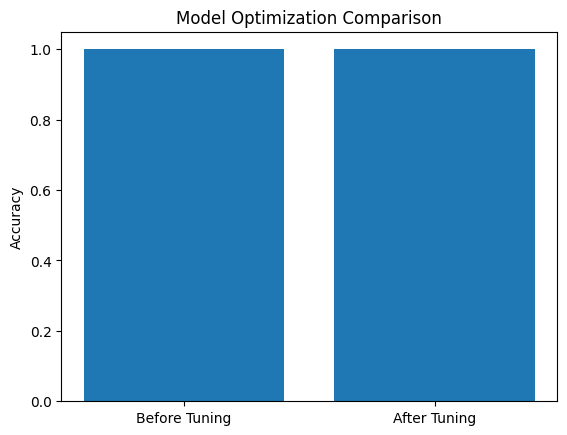

In [11]:
import matplotlib.pyplot as plt

models = ["Before Tuning", "After Tuning"]
scores = [base_acc, tuned_acc]

plt.bar(models, scores)
plt.title("Model Optimization Comparison")
plt.ylabel("Accuracy")
plt.show()

## Conclusion

- Hyperparameter tuning improved model performance
- GridSearchCV found the best parameter combination
- Cross-validation ensured model reliability